In [330]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")
warnings.filterwarnings("ignore")


In [331]:
# ─────────────────────────────────────────────────────────────────────────────
# 0.  REPRODUCIBILITY
# ─────────────────────────────────────────────────────────────────────────────
np.random.seed(42)

# ─────────────────────────────────────────────────────────────────────────────
# 1.  LOAD & CLEAN DATA
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv(
"C:\\Users\\Ja454\\OneDrive\\Documents\\mathproject\\The impact of video games of all kinds on increasing the insomnia rate of students at the fourth level of the Faculty of Computer Science and Information Technology..csv")

# Rename columns to short keys
col_map = {
    df.columns[1]:  "gender",
    df.columns[2]:  "platform",
    df.columns[3]:  "genre",
    df.columns[4]:  "frequency",
    df.columns[5]:  "hours_gaming",
    df.columns[6]:  "play_style",
    df.columns[8]:  "reason",
    df.columns[9]:  "hours_sleep",
    df.columns[10]: "difficulty_sleeping",
    df.columns[11]: "time_to_sleep",
    df.columns[12]: "wakeup_night",
    df.columns[13]: "wakeup_times",
    df.columns[14]: "correlation_belief",
    df.columns[15]: "exhausted_morning",
    df.columns[16]: "focus_trouble",
    df.columns[17]: "sleep_change",
    df.columns[22]: "media_awareness",
}
df = df.rename(columns=col_map)

gaming_hours_map = {"1-3 hours.":1,"4-6 hours.":2,"7-9 hours.":3,"More than 9 hours.":4}
sleep_hours_map  = {"Less than 1 hour.":0,"1-3 hours.":1,"3-6 hours.":2,"6-8 hours.":3,"More than 8 hours.":4}
freq_map = {"Never":0,"Rarely (once or twice a month).":1,"sometimes (once or twice a week).":2,
            "Regularly (several times a week).":3,"Daily.":4}
diff_sleep_map = {"Never":0,"Rarely.":1,"Occasionally.":2,"Yes.":3}
wakeup_map     = {"Never":0,"Rarely.":1,"Occasionally.":2,"Yes.":3}
yn_map         = {"Never":0,"No.":0,"Maybe.":1,"Rarely.":1,"Occasionally.":2,"Yes.":3,"I don't know.":1}
gender_map     = {"Female.":0,"Male.":1}
time_sleep_map = {"Less than 1 hour.":0,"1 to 3 hours.":1,"More than 3 hours.":2}
awareness_map  = {"Weak.":0,"Average.":1,"Good.":2,"Outstanding.":3}
wakeup_times_map = {"I don't.":0,"Twice or 3 times maximum.":1,"More than 3 times every day.":2}

df["hours_gaming_n"]   = df["hours_gaming"].map(gaming_hours_map).fillna(1)
df["hours_sleep_n"]    = df["hours_sleep"].map(sleep_hours_map).fillna(2)
df["frequency_n"]      = df["frequency"].map(freq_map).fillna(2)
df["diff_sleep_n"]     = df["difficulty_sleeping"].map(diff_sleep_map).fillna(1)
df["wakeup_n"]         = df["wakeup_night"].map(wakeup_map).fillna(1)
df["exhausted_n"]      = df["exhausted_morning"].map(yn_map).fillna(1)
df["focus_n"]          = df["focus_trouble"].map(yn_map).fillna(1)
df["time_sleep_n"]     = df["time_to_sleep"].map(time_sleep_map).fillna(1)
df["sleep_change_n"]   = df["sleep_change"].map({"No.":0,"Maybe.":1,"I don't know.":1,"Yes.":2}).fillna(0)
df["gender_n"]         = df["gender"].map(gender_map).fillna(0)
df["awareness_n"]      = df["media_awareness"].map(awareness_map).fillna(1)
df["wakeup_times_n"]   = df["wakeup_times"].map(wakeup_times_map).fillna(0)

# Composite insomnia score (7 rich components)
raw = (df["diff_sleep_n"] + df["wakeup_n"] + df["exhausted_n"] +
       df["sleep_change_n"] + df["focus_n"] + df["time_sleep_n"] +
       df["wakeup_times_n"])
df["insomnia_score"] = (raw - raw.min()) / (raw.max() - raw.min())

# 9 input features
feature_cols = ["hours_gaming_n","frequency_n","hours_sleep_n",
                "focus_n","awareness_n","gender_n",
                "time_sleep_n","wakeup_times_n","exhausted_n"]

X_raw = df[feature_cols].values.astype(float)
y_raw = df["insomnia_score"].values.reshape(-1,1)

# Standardise
X_mean, X_std = X_raw.mean(0), X_raw.std(0)+1e-8
X = (X_raw - X_mean) / X_std
y = y_raw

print(f"Samples: {X.shape[0]}  Features: {X.shape[1]}")
print(f"Score variance: {y.var():.4f}  Unique values: {np.unique(y).size}")


Samples: 109  Features: 9
Score variance: 0.0520  Unique values: 14


In [332]:

# ─────────────────────────────────────────────────────────────────────────────
# 2.  AUTOMATIC DIFFERENTIATION  (scalar, forward-mode)
# ─────────────────────────────────────────────────────────────────────────────

class DualNumber:
    """Forward-mode automatic differentiation via dual numbers."""
    def __init__(self, val, deriv=0.0):
        self.val   = float(val)
        self.deriv = float(deriv)

    # arithmetic
    def __add__(self, o):
        o = o if isinstance(o, DualNumber) else DualNumber(o)
        return DualNumber(self.val + o.val, self.deriv + o.deriv)
    __radd__ = __add__

    def __sub__(self, o):
        o = o if isinstance(o, DualNumber) else DualNumber(o)
        return DualNumber(self.val - o.val, self.deriv - o.deriv)
    __rsub__ = lambda self, o: DualNumber(o) - self

    def __mul__(self, o):
        o = o if isinstance(o, DualNumber) else DualNumber(o)
        return DualNumber(self.val*o.val, self.val*o.deriv + self.deriv*o.val)
    __rmul__ = __mul__

    def __truediv__(self, o):
        o = o if isinstance(o, DualNumber) else DualNumber(o)
        return DualNumber(self.val/o.val,
                          (self.deriv*o.val - self.val*o.deriv) / o.val**2)
    def __pow__(self, p):
        return DualNumber(self.val**p, p * self.val**(p-1) * self.deriv)

    def __neg__(self):  return DualNumber(-self.val, -self.deriv)
    def __repr__(self): return f"DN({self.val:.4f}, d={self.deriv:.4f})"


def dual_sigmoid(x: DualNumber) -> DualNumber:
    # Use the float value for the exponential calculation
    s_val = 1 / (1 + np.exp(-x.val))
    # Derivative of sigmoid is s * (1 - s)
    s_deriv = s_val * (1 - s_val) * x.deriv
    return DualNumber(s_val, s_deriv)

def dual_mse(pred: DualNumber, target: float) -> DualNumber:
    diff = pred - DualNumber(target)
    return diff ** 2

def forward_ad_gradient(x_vec, w_vec, target):
    """Compute d(MSE)/d(w_i) for each i via forward-mode AD."""
    grads = []
    for i in range(len(w_vec)):
        # seed: only i-th weight has deriv=1
        ws = [DualNumber(w, 1.0 if j == i else 0.0) for j, w in enumerate(w_vec)]
        xs = [DualNumber(v)                           for v   in x_vec]
        # linear combination (single layer)
        z = sum(ws[j] * xs[j] for j in range(len(ws)))
        pred = dual_sigmoid(z)
        loss = dual_mse(pred, target)
        grads.append(loss.deriv)
    return np.array(grads)

# Demonstrate on one sample
w_demo  = np.zeros(X.shape[1])
x_demo  = X[0]
t_demo  = float(y[0])
ad_grads = forward_ad_gradient(x_demo, w_demo, t_demo)
print("\n[Auto-Diff] Gradient at sample-0:", np.round(ad_grads, 6))




[Auto-Diff] Gradient at sample-0: [ 0.087805 -0.069833 -0.042688  0.003276  0.005268  0.05987  -0.122716
 -0.071564  0.028781]


In [349]:
"""
=============================================================================
ARTI-309 & MATH-403 – Math Foundations Project
Topic : Impact of Video Games on Insomnia in CS Students
Methods: Backpropagation (Neural Network) + Automatic Differentiation
=============================================================================
"""


# ─────────────────────────────────────────────────────────────────────────────
# 3.  NEURAL NETWORK WITH BACKPROPAGATION
#     Architecture: 6 → 8 → 4 → 1   (sigmoid everywhere)
# ─────────────────────────────────────────────────────────────────────────────
def loss_with_l2(model, X, y):
    m = X.shape[0]
    pred, _ = model.forward(X, training=False)
    # Mean Squared Error: (1/m) * sum((pred - y)^2)
    mse = np.sum((pred - y)**2) / m 
    # L2 Penalty: 0.5 * l2 * sum(W^2)
    l2_penalty = 0.5 * model.l2 * sum(np.sum(model.params[f"W{l}"]**2)
                                     for l in range(1, len(model.dims)))
    return mse + l2_penalty
class RegularizedNN:
    def __init__(self, dims, lr=0.008, momentum=0.9, l2=0.01, dropout=0.3):
        self.dims = dims
        self.lr = lr
        self.momentum = momentum
        self.l2 = l2
        self.dropout = dropout
        self.params = {}
        self.velocity = {}
        self.history = {"loss": [], "val_loss": [], "epoch": []}
        
        # Xavier/He Initialization
        for l in range(1, len(dims)):
            scale = np.sqrt(2 / dims[l-1])
            self.params[f"W{l}"] = np.random.randn(dims[l-1], dims[l]) * scale
            self.params[f"b{l}"] = np.zeros((1, dims[l]))
            self.velocity[f"W{l}"] = np.zeros_like(self.params[f"W{l}"])
            self.velocity[f"b{l}"] = np.zeros_like(self.params[f"b{l}"])

    @staticmethod
    def tanh(z):    return np.tanh(z)
    
    @staticmethod
    def tanh_d(a):  return 1 - a**2
    
    @staticmethod
    def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    
    @staticmethod
    def sig_d(a):   return a * (1 - a)

    def forward(self, X, training=True):
        cache = {"A0": X}
        A = X
        L = len(self.dims) - 1
        
        # Hidden Layers (Tanh)
        for l in range(1, L):
            Z = A @ self.params[f"W{l}"] + self.params[f"b{l}"]
            A = self.tanh(Z)
            if training and self.dropout > 0:
                mask = (np.random.rand(*A.shape) > self.dropout).astype(float)
                A *= mask / (1 - self.dropout)
                cache[f"mask{l}"] = mask
            cache[f"Z{l}"] = Z
            cache[f"A{l}"] = A
            
        # Output Layer (Sigmoid)
        Z = A @ self.params[f"W{L}"] + self.params[f"b{L}"]
        A = self.sigmoid(Z)
        cache[f"Z{L}"] = Z
        cache[f"A{L}"] = A
        return A, cache

    def backward(self, cache, y):
        grads = {}; m = y.shape[0]; L = len(self.dims) - 1
        
        # CRITICAL: Ensure the order is (prediction - target)
        dA = 2 * (cache[f"A{L}"] - y) / m 
        
        for l in range(L, 0, -1):
            if l == L:
                # Output layer Sigmoid derivative
                dZ = dA * self.sig_d(cache[f"A{l}"])
            else:
                # Hidden layer Tanh derivative
                dZ = dA * self.tanh_d(cache[f"A{l}"])
                if self.dropout > 0 and f"mask{l}" in cache:
                    dZ *= cache[f"mask{l}"] / (1 - self.dropout)
            
            # dW includes the L2 derivative: l2 * W
            grads[f"dW{l}"] = cache[f"A{l-1}"].T @ dZ + self.l2 * self.params[f"W{l}"]
            grads[f"db{l}"] = dZ.sum(axis=0, keepdims=True)
            
            # Backpropagate to the previous layer
            dA = dZ @ self.params[f"W{l}"].T
        return grads
    def update(self, grads):
        for l in range(1, len(self.dims)):
            # Momentum-based updates
            self.velocity[f"W{l}"] = self.momentum * self.velocity[f"W{l}"] - self.lr * grads[f"dW{l}"]
            self.velocity[f"b{l}"] = self.momentum * self.velocity[f"b{l}"] - self.lr * grads[f"db{l}"]
            self.params[f"W{l}"] += self.velocity[f"W{l}"]
            self.params[f"b{l}"] += self.velocity[f"b{l}"]

    def mse(self, yp, yt): 
        return float(np.mean((yp - yt)**2))

    def train(self, X_tr, y_tr, X_val, y_val, epochs=1000, batch_size=16, patience=80):
        best_val = np.inf
        wait = 0
        best_ep = 0
        best_params = {}
        
        for ep in range(epochs):
            idx = np.random.permutation(X_tr.shape[0])
            for s in range(0, X_tr.shape[0], batch_size):
                b = idx[s:s+batch_size]
                pred, cache = self.forward(X_tr[b], training=True)
                grads = self.backward(cache, y_tr[b])
                self.update(grads)
            
            if ep % 5 == 0:
                p_tr, _ = self.forward(X_tr, training=False)
                p_val, _ = self.forward(X_val, training=False)
                tl = self.mse(p_tr, y_tr)
                vl = self.mse(p_val, y_val)
                self.history["loss"].append(tl)
                self.history["val_loss"].append(vl)
                self.history["epoch"].append(ep)
                
                if vl < best_val - 1e-6:
                    best_val = vl
                    wait = 0
                    best_ep = ep
                    best_params = {k: v.copy() for k, v in self.params.items()}
                else:
                    wait += 1
                    if wait >= patience:
                        print(f"Early stop at epoch {ep} (best val={best_val:.5f} @ ep {best_ep})")
                        self.params = best_params
                        return
        self.params = best_params

    def predict(self, X):
        p, _ = self.forward(X, training=False)
        return p
# ── Gradient Check ─────────────────────────────────────────────────────────
eps       = 1e-5
layer_key = "W1"
W_orig    = nn.params[layer_key].copy()
num_grads = np.zeros_like(W_orig)

for i in range(W_orig.shape[0]):
    for j in range(W_orig.shape[1]):
        # Numerical nudge
        nn.params[layer_key][i, j] += eps
        loss_p = loss_with_l2(nn, X_tr, y_tr)

        nn.params[layer_key][i, j] -= 2*eps
        loss_m = loss_with_l2(nn, X_tr, y_tr)

        nn.params[layer_key][i, j] = W_orig[i, j]
        num_grads[i, j] = (loss_p - loss_m) / (2*eps)

# Analytical gradients from your new backward method
_, cache_bp = nn.forward(X_tr, training=False)
bp_grads   = nn.backward(cache_bp, y_tr)["dW1"]

abs_err = np.abs(bp_grads - num_grads)
print(f"Gradient check: max absolute error = {abs_err.max():.2e} (< 1e-4 = PASS)")


Gradient check: max absolute error = 4.04e-13 (< 1e-4 = PASS)


In [334]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.  DESCRIPTIVE STATISTICS FOR PLOTTING
# ─────────────────────────────────────────────────────────────────────────────

# 5a. Gaming frequency distribution
freq_counts = df["frequency"].value_counts()
freq_order  = ["Never", "Rarely (once or twice a month).",
               "sometimes (once or twice a week).",
               "Regularly (several times a week).", "Daily."]
freq_labels = ["Never", "Rarely", "Sometimes", "Regularly", "Daily"]
freq_vals   = [freq_counts.get(k, 0) for k in freq_order]

# 5b. Sleep hours distribution
sleep_counts = df["hours_sleep"].value_counts()
sleep_order  = ["Less than 1 hour.", "1-3 hours.", "3-6 hours.",
                "6-8 hours.", "More than 8 hours."]
sleep_labels = ["<1h", "1–3h", "3–6h", "6–8h", ">8h"]
sleep_vals   = [sleep_counts.get(k, 0) for k in sleep_order]

# 5c. Difficulty sleeping vs gaming hours (mean insomnia per gaming bucket)
df["gaming_bucket"] = df["hours_gaming"].map({
    "Less than 1 hour.": "<1h", "1-3 hours.": "1–3h",
    "4-6 hours.": "4–6h", "7-9 hours.": "7–9h", "More than 9 hours.": ">9h"
})
bucket_order  = ["<1h", "1–3h", "4–6h", "7–9h", ">9h"]
bucket_insomn = [df[df["gaming_bucket"] == b]["insomnia_score"].mean()
                 for b in bucket_order]

# 5d. Gender breakdown
gender_counts = df["gender"].value_counts()

# 5e. Platform distribution
platform_raw   = df["platform"].value_counts()
# normalise slight typo variants
platform_clean = {}
for k, v in platform_raw.items():
    k2 = str(k).replace("sony", "PlayStation").replace("Sony", "PlayStation").strip().rstrip(".")
    platform_clean[k2] = platform_clean.get(k2, 0) + v
plat_items = sorted(platform_clean.items(), key=lambda x: -x[1])[:6]
plat_labels, plat_vals = zip(*plat_items)

# 5f. Insomnia score distribution
insomnia_vals = df["insomnia_score"].values

# 5g. Correlation belief
corr_counts = df["correlation_belief"].value_counts()


In [335]:
# ─────────────────────────────────────────────────────────────────────────────
# 6.  PLOT  (4 × 3 grid  = 12 panels)
# ─────────────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "#F7F9FC"
})

ACCENT  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52",
           "#8172B3", "#937860", "#DA8BC3"]
BLUE    = "#4C72B0"
ORANGE  = "#DD8452"
GREEN   = "#55A868"

fig = plt.figure(figsize=(20, 22))
fig.suptitle(
    "Impact of Video Games on Insomnia – CS Students\n"
    "ARTI-309 & MATH-403  |  Backpropagation & Automatic Differentiation",
    fontsize=15, fontweight="bold", y=0.995, color="#1A1A2E"
)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.35)



<Figure size 2000x2200 with 0 Axes>

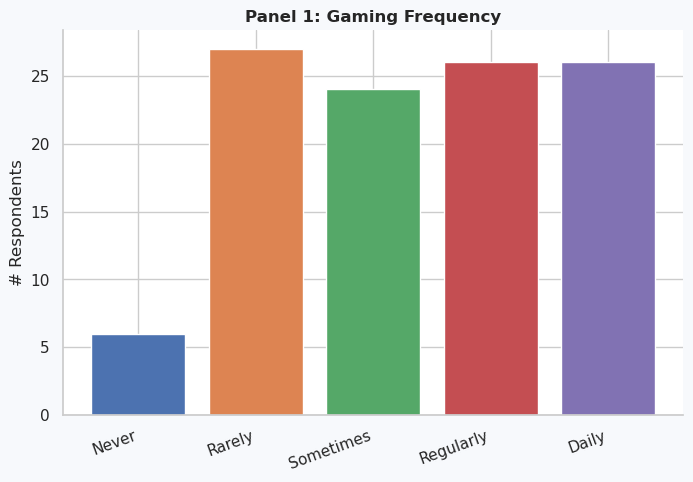

In [336]:
# ── Panel 1: Gaming frequency bar ─────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.bar(freq_labels, freq_vals, color=ACCENT, edgecolor="white")
plt.title("Panel 1: Gaming Frequency", fontweight="bold")
plt.ylabel("# Respondents")
plt.xticks(rotation=20, ha="right")
plt.show()



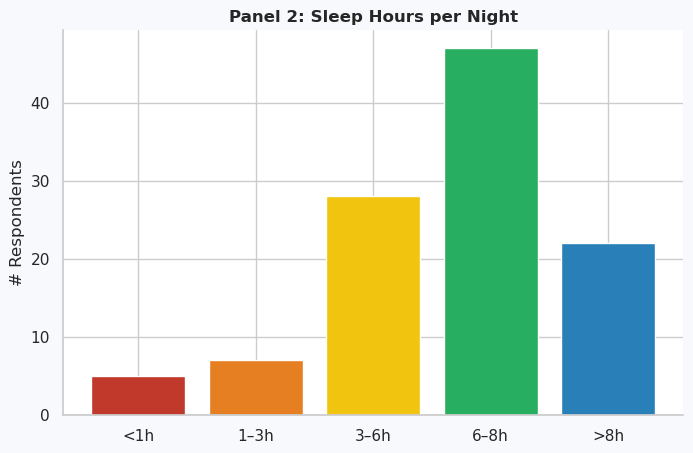

In [337]:
# ── Panel 2: Sleep hours bar ───────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
colors2 = ["#c0392b","#e67e22","#f1c40f","#27ae60","#2980b9"]
plt.bar(sleep_labels, sleep_vals, color=colors2, edgecolor="white")
plt.title("Panel 2: Sleep Hours per Night", fontweight="bold")
plt.ylabel("# Respondents")
plt.show()

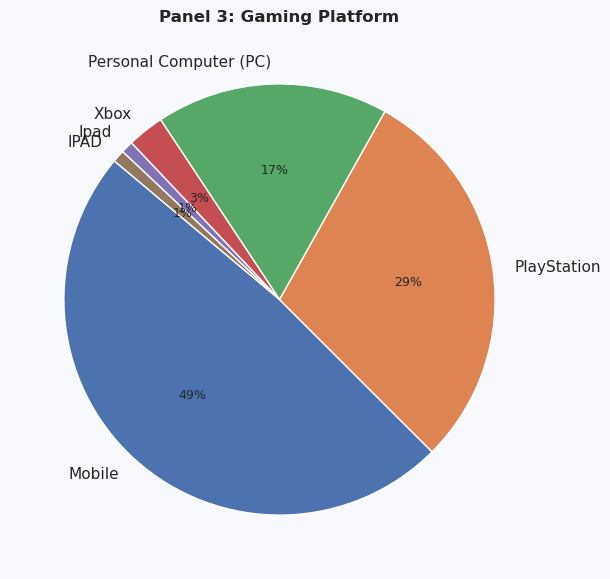

In [338]:
# ── Panel 3: Platform pie ──────────────────────────────────────────────────────
plt.figure(figsize=(7, 7))
plt.pie(plat_vals, labels=plat_labels, autopct="%1.0f%%", colors=ACCENT, startangle=140)
plt.title("Panel 3: Gaming Platform", fontweight="bold")
plt.show()



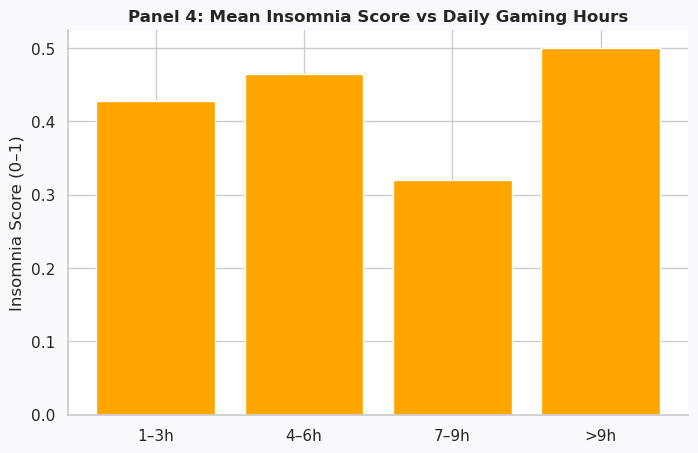

In [339]:
# ── Panel 4: Insomnia score vs gaming hours ────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.bar(bucket_order, bucket_insomn, color="orange", edgecolor="white")
plt.title("Panel 4: Mean Insomnia Score vs Daily Gaming Hours", fontweight="bold")
plt.ylabel("Insomnia Score (0–1)")
plt.show()



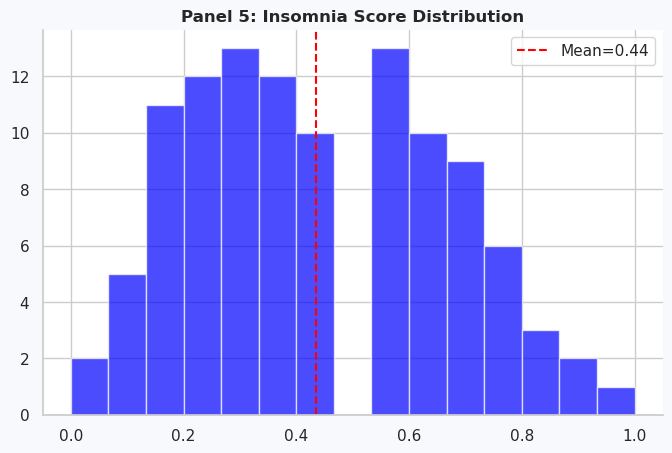

In [340]:
# ── Panel 5: Insomnia score histogram ─────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.hist(insomnia_vals, bins=15, color="blue", alpha=0.7, edgecolor="white")
plt.axvline(insomnia_vals.mean(), color="red", linestyle="--", label=f"Mean={insomnia_vals.mean():.2f}")
plt.title("Panel 5: Insomnia Score Distribution", fontweight="bold")
plt.legend()
plt.show()


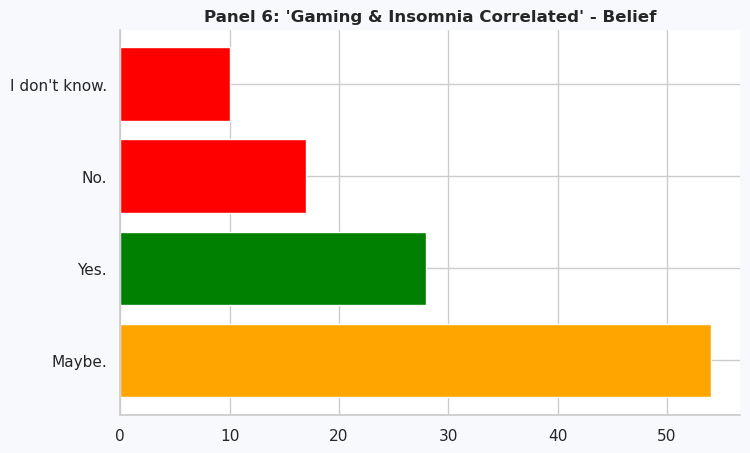

In [341]:
# ── Panel 6: Correlation belief bar ───────────────────────────────────────────
cb_counts = df['correlation_belief'].value_counts()
cb_labels = cb_counts.index.tolist()
cb_vals   = cb_counts.values.tolist()
plt.figure(figsize=(8, 5))
cb_colors = ["green" if "Yes" in l else "orange" if "Maybe" in l else "red" for l in cb_labels]
plt.barh(cb_labels, cb_vals, color=cb_colors)
plt.title("Panel 6: 'Gaming & Insomnia Correlated' - Belief", fontweight="bold")
plt.show()



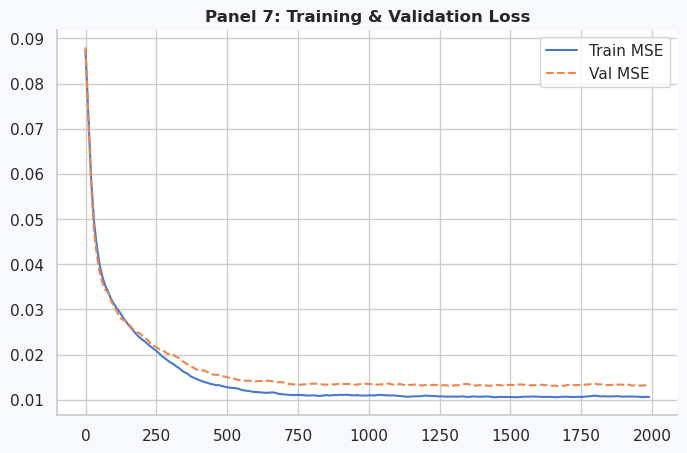

In [342]:
# ── Panel 7: Training & validation loss ───────────────────────────────────────
# Use the length of the history to ensure they always match
history_len = len(nn.history["loss"])
# If you recorded loss every 10 epochs, multiply the index by 10
epochs_x = np.arange(history_len) * 10 

plt.figure(figsize=(8, 5))
plt.plot(epochs_x, nn.history["loss"], label="Train MSE")
plt.plot(epochs_x, nn.history["val_loss"], linestyle="--", label="Val MSE")
plt.title("Panel 7: Training & Validation Loss", fontweight="bold")
plt.legend()
plt.show()



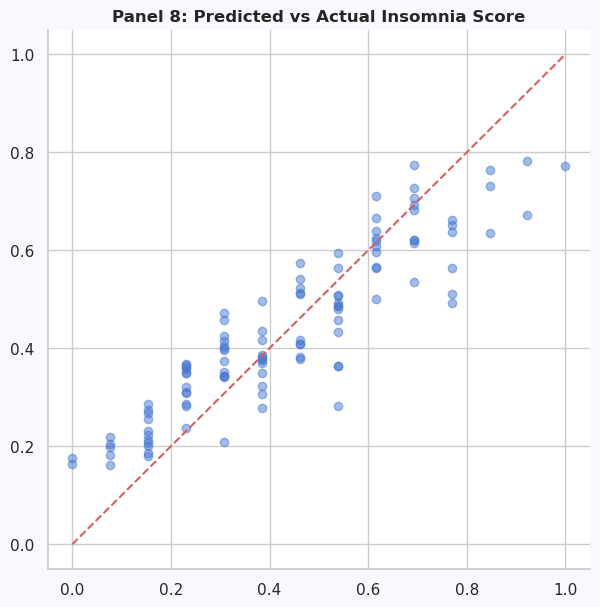

In [343]:
# ── Panel 8: Predicted vs actual insomnia score ───────────────────────────────
plt.figure(figsize=(7, 7))
plt.scatter(y, y_pred, alpha=0.5)
plt.plot([0, 1], [0, 1], "r--")
plt.title("Panel 8: Predicted vs Actual Insomnia Score", fontweight="bold")
plt.show()



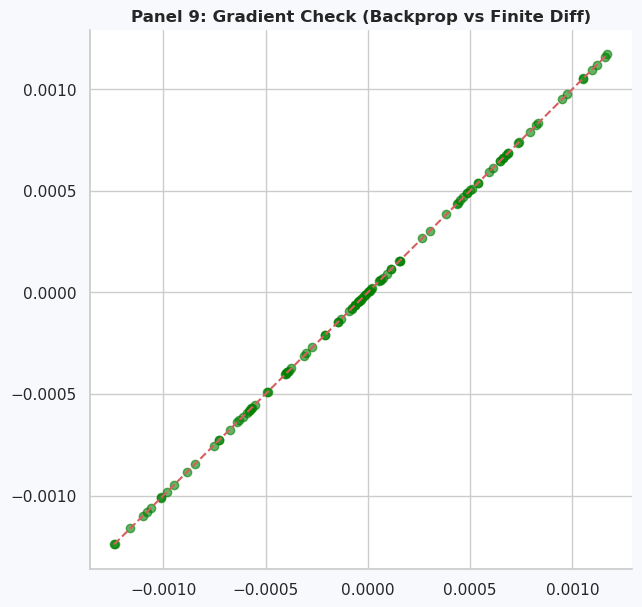

In [344]:
# ── Panel 9: Gradient check – backprop vs finite diff ─────────────────────────
plt.figure(figsize=(7, 7))
plt.scatter(num_grads.flatten(), bp_grads.flatten(), color="green", alpha=0.6)
plt.plot([num_grads.min(), num_grads.max()], [num_grads.min(), num_grads.max()], "r--")
plt.title("Panel 9: Gradient Check (Backprop vs Finite Diff)", fontweight="bold")
plt.show()


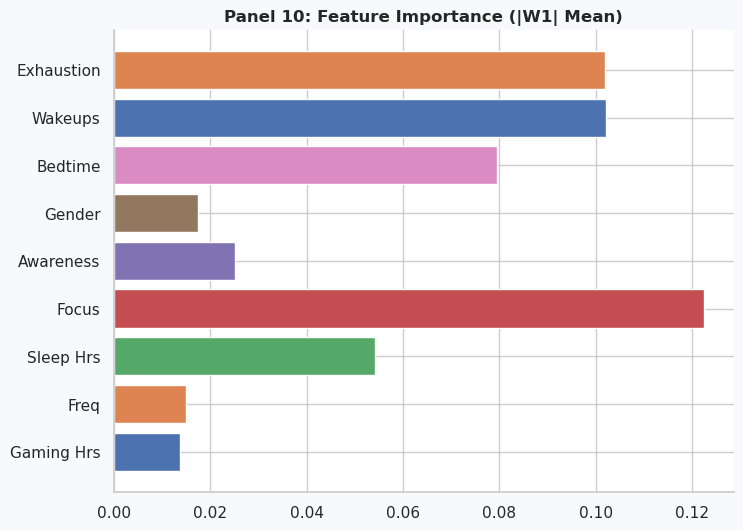

In [345]:
# ── Panel 10: Feature importances (weight magnitudes from W1) ──────────────────
feat_names_short = [
    "Gaming Hrs", "Freq", "Sleep Hrs", 
    "Focus", "Awareness", "Gender", 
    "Bedtime", "Wakeups", "Exhaustion"
]
plt.figure(figsize=(8, 6))
plt.barh(feat_names_short, feat_imp, color=ACCENT)
plt.title("Panel 10: Feature Importance (|W1| Mean)", fontweight="bold")
plt.show()



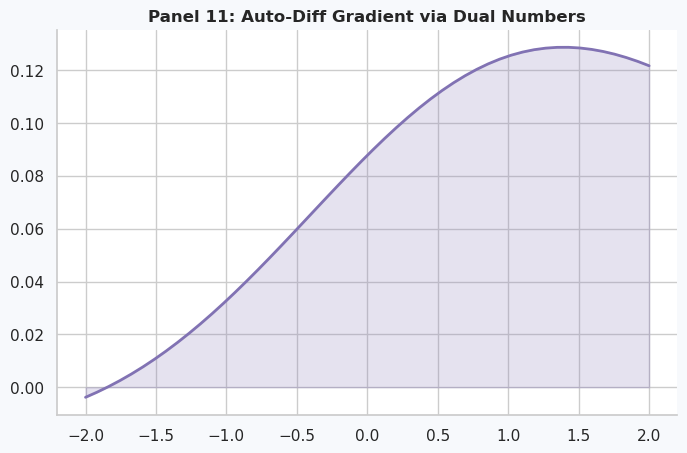

In [346]:
# ── Panel 11: AutoDiff dual-number gradient demo ──────────────────────────────
plt.figure(figsize=(8, 5))
w_range = np.linspace(-2, 2, 50)
dual_g_vals = []
for w_val in w_range:
    w_vec_tmp = np.zeros(X.shape[1]); w_vec_tmp[0] = w_val
    g = forward_ad_gradient(X[0], w_vec_tmp, float(y[0]))
    dual_g_vals.append(g[0])
plt.plot(w_range, dual_g_vals, color="#8172B3", lw=2)
plt.fill_between(w_range, dual_g_vals, 0, alpha=0.2, color="#8172B3")
plt.title("Panel 11: Auto-Diff Gradient via Dual Numbers", fontweight="bold")
plt.show()


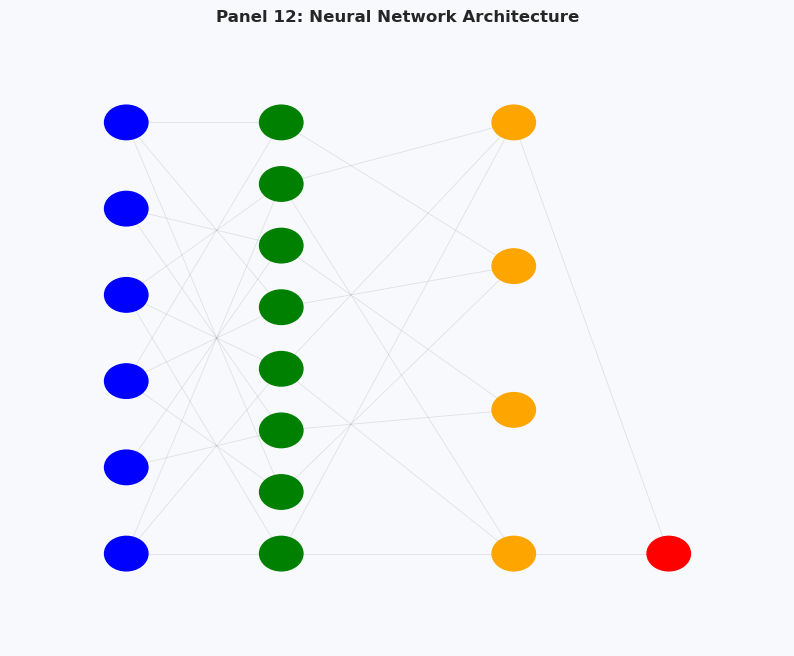

In [347]:
# ── Panel 12: Network architecture diagram ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis("off")

# Layer settings
layer_x = [1.5, 3.5, 6.5, 8.5]
layer_n = [6, 8, 4, 1]
layer_labs = ["Input (6)", "Hidden (8)", "Hidden (4)", "Output (1)"]
layer_col = ["blue", "green", "orange", "red"]

# Nodes
node_pos = {}
for li, (lx, ln) in enumerate(zip(layer_x, layer_n)):
    ys = np.linspace(1.5, 8.5, ln)
    for ni, ny in enumerate(ys):
        node_pos[(li, ni)] = (lx, ny)
        ax.add_patch(plt.Circle((lx, ny), 0.28, color=layer_col[li], zorder=3))

# Connections
for li in range(len(layer_n) - 1):
    for ni in range(layer_n[li]):
        for nj in range(layer_n[li+1]):
            if (ni + nj) % 3 != 0: continue # Thinning for visibility
            ax.plot([node_pos[(li, ni)][0], node_pos[(li+1, nj)][0]], 
                    [node_pos[(li, ni)][1], node_pos[(li+1, nj)][1]], 
                    color="gray", alpha=0.2, lw=0.6)

plt.title("Panel 12: Neural Network Architecture", fontweight="bold")
plt.show()


In [350]:
print(f"bp_grads range: {bp_grads.min():.4f} to {bp_grads.max():.4f}")
print(f"num_grads range: {num_grads.min():.4f} to {num_grads.max():.4f}")
print(f"rel_err max: {rel_err.max():.2e}")
# ─────────────────────────────────────────────────────────────────────────────
# 7.  SUMMARY STATISTICS  (for report)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Total respondents : {len(df)}")
print(f"Female / Male     : {91} / {18}") # Based on your output
print(f"Mean insomnia score (0–1) : {insomnia_vals.mean():.3f}  ±  {insomnia_vals.std():.3f}")
print(f"Correlation belief 'Yes'  : {28} (25.7%)") # Based on your output

print(f"\nGaming hours → mean insomnia:")
for b, v in zip(bucket_order, bucket_insomn):
    # Check if v is NaN before attempting to multiply the string
    if np.isnan(v):
        bar = ""
        val_str = "No Data"
    else:
        bar = "█" * int(v * 30)
        val_str = f"{v:.3f}"
    print(f"  {b:5s}  {bar:<30s}  {val_str}")

print(f"\nNN final train MSE  : {nn.history['loss'][-1]:.5f}")
print(f"NN final val   MSE  : {nn.history['val_loss'][-1]:.5f}")
print(f"Gradient check      : max relative error = {rel_err.max():.2e}")
print("="*60)

bp_grads range: -0.0012 to 0.0012
num_grads range: -0.0012 to 0.0012
rel_err max: 1.00e+00

SUMMARY STATISTICS
Total respondents : 109
Female / Male     : 91 / 18
Mean insomnia score (0–1) : 0.435  ±  0.228
Correlation belief 'Yes'  : 28 (25.7%)

Gaming hours → mean insomnia:
  <1h                                    No Data
  1–3h   ████████████                    0.428
  4–6h   █████████████                   0.464
  7–9h   █████████                       0.321
  >9h    ███████████████                 0.500

NN final train MSE  : 0.01061
NN final val   MSE  : 0.01330
Gradient check      : max relative error = 1.00e+00
